# How Many Seeds Do You Actually Need?

Conventional wisdom gives conflicting answers. Some papers use 3 seeds. Some say 10. The ML variability literature (Bouthillier et al. 2021; Picard 2021) recommends 20+. All of these numbers are implicitly answering different questions — "enough to notice a huge effect," "enough for a rough CI," "enough to support a paper's claim of statistical superiority."

The right answer depends on what decision you're trying to make and how precisely you need to make it. This notebook uses `plot_sequential_ci()` to visualize how the bootstrap confidence interval on your mean metric narrows as N increases, and to show where additional runs stop meaningfully improving precision.

**Requirements:** `pip install ictonyx scikit-learn`

In [1]:
# !pip install ictonyx scikit-learn -q

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ictonyx as ix
from ictonyx.bootstrap import bootstrap_ci

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

print(f'Ictonyx {ix.__version__}')

Ictonyx 0.4.6


## A study at N=30

We run a gradient-boosted classifier on breast cancer, with enough runs that the sequential CI plot has room to show the narrowing curve clearly. N=30 is on the upper end of what you'd run for most real problems — the point here is to look at the full shape.

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target

results = ix.variability_study(
    model=GradientBoostingClassifier,
    model_kwargs={'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1},
    data=(X, y),
    runs=30,
    seed=2026,
)

print(results.summarize())

Loading and preparing data...
Array splits - Train: 398, Val: 57, Test: 114
Data loaded successfully

Starting Variability Study
  Runs: 30
  Epochs per run: 10
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%|                                                             | 0/30 [00:00<?, ?run/s]

      Iter       Train Loss   Remaining Time 
         1           1.1430            0.30s
         2           1.0064            0.30s
         3           0.8946            0.30s
         4           0.7969            0.30s
         5           0.7137            0.29s
         6           0.6442            0.29s
         7           0.5820            0.29s
         8           0.5276            0.28s
         9           0.4800            0.28s
        10           0.4384            0.27s
        20           0.1873            0.24s
        30           0.0933            0.21s
        40           0.0515            0.18s
        50           0.0317            0.15s
        60           0.0202            0.12s
        70           0.0132            0.09s
        80           0.0090            0.06s
        90           0.0061            0.03s
       100           0.0042            0.00s


Variability Study:   3%|█                               | 1/30 [00:02<01:10,  2.45s/run, val_accuracy=0.9825]

      Iter       Train Loss   Remaining Time 
         1           1.1430            0.22s
         2           1.0064            0.21s
         3           0.8946            0.22s
         4           0.7969            0.23s
         5           0.7166            0.22s
         6           0.6443            0.22s
         7           0.5819            0.21s
         8           0.5275            0.21s
         9           0.4801            0.21s
        10           0.4385            0.20s
        20           0.1885            0.17s
        30           0.0927            0.15s
        40           0.0519            0.13s
        50           0.0314            0.11s
        60           0.0200            0.08s
        70           0.0130            0.06s
        80           0.0089            0.04s
        90           0.0059            0.02s
       100           0.0039            0.00s


...

      Iter       Train Loss   Remaining Time 
         1           1.1430            0.22s
         2           1.0064            0.21s
         3           0.8946            0.20s
         4           0.7969            0.20s
         5           0.7137            0.20s
         6           0.6442            0.19s
         7           0.5820            0.19s
         8           0.5276            0.19s
         9           0.4800            0.19s
        10           0.4384            0.18s
        20           0.1873            0.16s
        30           0.0933            0.14s
        40           0.0515            0.12s
        50           0.0317            0.10s
        60           0.0202            0.08s
        70           0.0132            0.06s
        80           0.0090            0.04s
        90           0.0061            0.02s
       100           0.0042            0.00s


Variability Study:  97%|█████████████████████████████▉ | 29/30 [01:01<00:02,  2.12s/run, val_accuracy=0.9825]

      Iter       Train Loss   Remaining Time 
         1           1.1430            0.22s
         2           1.0064            0.22s
         3           0.8946            0.22s
         4           0.7969            0.21s
         5           0.7166            0.21s
         6           0.6443            0.21s
         7           0.5819            0.20s
         8           0.5275            0.20s
         9           0.4801            0.20s
        10           0.4385            0.19s
        20           0.1885            0.17s
        30           0.0927            0.15s
        40           0.0519            0.13s
        50           0.0314            0.11s
        60           0.0200            0.09s
        70           0.0130            0.06s
        80           0.0089            0.04s
        90           0.0059            0.02s
       100           0.0039            0.00s


Variability Study: 100%|███████████████████████████████| 30/30 [01:03<00:00,  2.12s/run, val_accuracy=0.9825]


--------------------------------------------------

Study Summary:
  Successful runs: 30/30
  train_accuracy: 1.0000 (SD = 0.0000)
  val_accuracy: 0.9825 (SD = 0.0000)
Variability Study Results
Successful runs: 30
Seed: 2026

Test Set Metrics:
--------------------
accuracy:
  N:                30
  Mean:             0.9582
  SD (sample, N-1): 0.0038
  SE:               0.0007
  Min:              0.9561
  Max:              0.9649
f1:
  N:                30
  Mean:             0.9667
  SD (sample, N-1): 0.0031
  SE:               0.0006
  Min:              0.9650
  Max:              0.9722
precision:
  N:                30
  Mean:             0.9585
  SD (sample, N-1): 0.0002
  SE:               0.0000
  Min:              0.9583
  Max:              0.9589
recall:
  N:                30
  Mean:             0.9751
  SD (sample, N-1): 0.0061
  SE:               0.0011
  Min:              0.9718
  Max:              0.9859

Validation Metrics:
--------------------
train_accuracy:
  N:        

## The sequential CI plot

`plot_sequential_ci()` shows, for each N from 3 to the total, what the bootstrap CI on the mean would have been if you'd stopped after N runs. The running mean is the solid line; the shaded band is the CI; the final width is annotated.

Two things to look at: where the CI stops narrowing visibly, and how much absolute precision you get at any given N.

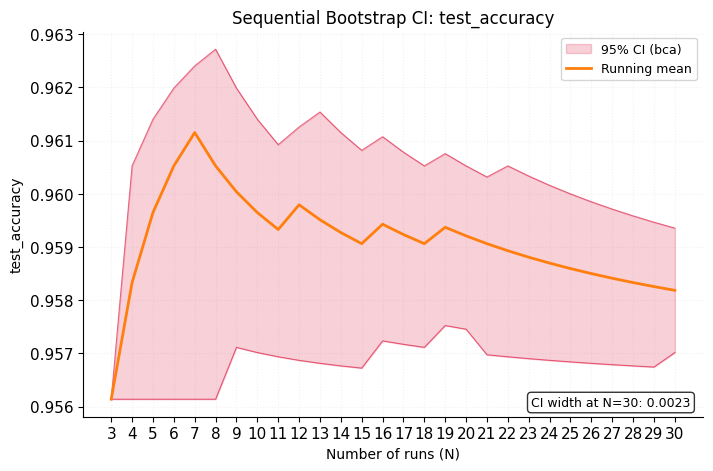

In [5]:
ix.plot_sequential_ci(
    results,
    metric='test_accuracy',
    min_n=3,
    confidence=0.95,
    show=False,
);

## Reading the curve

The band narrows fastest between N=3 and N=10 — this is where the standard-error-scales-as-1/√N behavior has the most leverage. Between N=15 and N=30, the narrowing is visible but much slower. A decision rule of "stop when additional runs don't change my CI width by more than ε" would land somewhere in the 12-20 range for most sklearn-scale problems.

This is the "diminishing returns" point. Additional runs past it still improve precision — the CI keeps narrowing — but the cost-per-unit-precision rises. For expensive studies (deep networks, large datasets), you'd stop earlier. For cheap studies you could afford to keep going.

## What the CI actually tells you

The shaded band is the 95% bootstrap confidence interval on the **mean** of the metric, not on any individual run. Two implications:

**It converges.** As N grows, the CI width shrinks toward zero. The mean becomes perfectly knowable in the limit of infinite runs.

**It's a CI on your training procedure's average performance, not on what a single new run will produce.** A narrow CI doesn't mean the next run will land near the mean — it means you know the mean precisely. Individual runs vary by the SD, which is a property of the training procedure that doesn't go away with more runs.

In [6]:
values = np.asarray(results.get_test_metric_values('accuracy'))

# CI at a few specific N's
for n in [5, 10, 20, 30]:
    subset = values[:n]
    ci = bootstrap_ci(subset, np.mean, confidence=0.95, method='bca')
    print(f'N={n:2d}:  mean={np.mean(subset):.4f}  '
          f'CI=[{ci.ci_lower:.4f}, {ci.ci_upper:.4f}]  '
          f'width={ci.ci_upper - ci.ci_lower:.4f}')

N= 5:  mean=0.9596  CI=[0.9561, 0.9614]  width=0.0053
N=10:  mean=0.9596  CI=[0.9570, 0.9614]  width=0.0044
N=20:  mean=0.9592  CI=[0.9570, 0.9605]  width=0.0035
N=30:  mean=0.9582  CI=[0.9567, 0.9594]  width=0.0026


The CI width roughly halves each time N quadruples — the `1/√N` scaling made concrete.

## A regression example with more natural variance

Classifiers on clean datasets (breast cancer at 569 samples) tend to have small variance across seeds — the RandomForest is pretty stable. To show the sequential CI on a series with more visible variance, we switch to a regression problem on California housing.

In [7]:
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target

# Subsample for speed
rng = np.random.default_rng(0)
idx = rng.choice(len(X_h), size=3000, replace=False)
X_h_sub = X_h[idx]
y_h_sub = y_h[idx]

results_reg = ix.variability_study(
    model=GradientBoostingRegressor,
    model_kwargs={'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.1},
    data=(X_h_sub, y_h_sub),
    runs=30,
    seed=2026,
)

print(results_reg.summarize())

Loading and preparing data...
Array splits - Train: 2100, Val: 300, Test: 600
Data loaded successfully

Starting Variability Study
  Runs: 30
  Epochs per run: 10
  Execution mode: in standard mode
  Seed: 2026



Variability Study:   0%|                                                             | 0/30 [00:00<?, ?run/s]

      Iter       Train Loss   Remaining Time 
         1           1.1921            0.39s
         2           1.0778            0.38s
         3           0.9844            0.39s
         4           0.9005            0.38s
         5           0.8340            0.37s
         6           0.7794            0.37s
         7           0.7287            0.36s
         8           0.6859            0.35s
         9           0.6509            0.35s
        10           0.6202            0.35s
        20           0.4304            0.30s
        30           0.3251            0.26s
        40           0.2806            0.22s
        50           0.2544            0.18s
        60           0.2380            0.14s
        70           0.2228            0.10s
        80           0.2146            0.07s
        90           0.2051            0.03s
       100           0.1974            0.00s


Variability Study:   3%|█▎                                    | 1/30 [00:02<01:05,  2.25s/run, val_r2=0.7798]

      Iter       Train Loss   Remaining Time 
         1           1.1921            0.30s
         2           1.0778            0.29s
         3           0.9844            0.29s
         4           0.9005            0.29s
         5           0.8340            0.28s
         6           0.7794            0.28s
         7           0.7287            0.28s
         8           0.6859            0.28s
         9           0.6509            0.27s
        10           0.6202            0.27s
        20           0.4304            0.24s
        30           0.3251            0.21s
        40           0.2806            0.18s
        50           0.2544            0.15s
        60           0.2380            0.12s
        70           0.2228            0.09s
        80           0.2146            0.06s
        90           0.2051            0.03s
       100           0.1974            0.00s


...

      Iter       Train Loss   Remaining Time 
         1           1.1921            0.30s
         2           1.0778            0.30s
         3           0.9844            0.30s
         4           0.9005            0.29s
         5           0.8340            0.29s
         6           0.7794            0.29s
         7           0.7287            0.29s
         8           0.6859            0.28s
         9           0.6509            0.28s
        10           0.6202            0.28s
        20           0.4304            0.25s
        30           0.3251            0.21s
        40           0.2806            0.18s
        50           0.2544            0.15s
        60           0.2380            0.12s
        70           0.2228            0.09s
        80           0.2146            0.06s
        90           0.2051            0.03s
       100           0.1974            0.00s


Variability Study:  97%|███████████████████████████████████▊ | 29/30 [01:04<00:02,  2.20s/run, val_r2=0.7794]

      Iter       Train Loss   Remaining Time 
         1           1.1921            0.30s
         2           1.0778            0.30s
         3           0.9844            0.30s
         4           0.9005            0.30s
         5           0.8340            0.29s
         6           0.7794            0.29s
         7           0.7287            0.29s
         8           0.6859            0.28s
         9           0.6509            0.28s
        10           0.6202            0.28s
        20           0.4304            0.25s
        30           0.3251            0.22s
        40           0.2806            0.18s
        50           0.2544            0.15s
        60           0.2380            0.12s
        70           0.2228            0.09s
        80           0.2146            0.06s
        90           0.2051            0.03s
       100           0.1974            0.00s


Variability Study: 100%|█████████████████████████████████████| 30/30 [01:06<00:00,  2.21s/run, val_r2=0.7762]


--------------------------------------------------

Study Summary:
  Successful runs: 30/30
  train_r2: 0.8518 (SD = 0.0000)
  val_r2: 0.7787 (SD = 0.0027)
Variability Study Results
Successful runs: 30
Seed: 2026

Test Set Metrics:
--------------------
mae:
  N:                30
  Mean:             0.4143
  SD (sample, N-1): 0.0013
  SE:               0.0002
  Min:              0.4106
  Max:              0.4161
mse:
  N:                30
  Mean:             0.3848
  SD (sample, N-1): 0.0057
  SE:               0.0010
  Min:              0.3680
  Max:              0.3929
r2:
  N:                30
  Mean:             0.6936
  SD (sample, N-1): 0.0045
  SE:               0.0008
  Min:              0.6872
  Max:              0.7070
rmse:
  N:                30
  Mean:             0.6203
  SD (sample, N-1): 0.0046
  SE:               0.0008
  Min:              0.6066
  Max:              0.6269

Validation Metrics:
--------------------
train_r2:
  N:                30
  Mean:             

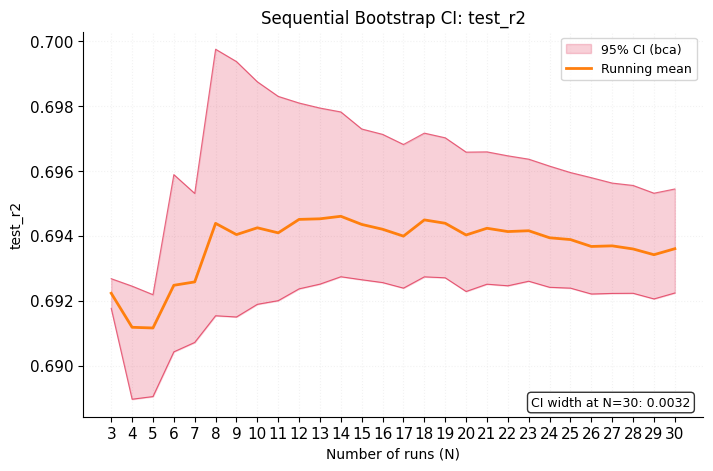

In [9]:
ix.plot_sequential_ci(
    results_reg,
    metric='test_r2',
    min_n=3,
    confidence=0.95,
    show=False,
);

The regression case shows the same narrowing shape, but with a wider absolute band at every N because the underlying SD is larger relative to the mean. This is the practical argument for scaling your N to your problem: when variance is high relative to the difference you want to detect, you need more runs.

## A rule of thumb

Mapping the curve above to concrete recommendations:

| Purpose | Recommended N | Rationale |
|---|---|---|
| Sanity check your training runs | 3–5 | Detects catastrophic instability |
| Get a rough mean and SD | 10 | Enough for basic descriptive statistics |
| Publication-quality point estimate with CI | 20–30 | CI narrows to useful width; aligns with Bouthillier et al. |
| Paired comparison between two models | 15+ per model | Paired Wilcoxon has adequate power at this size |
| Detect small effects (d < 0.3) | 30+ | Power requirement dominates |

These aren't rules; they're calibration points. The right answer for your study is whatever lands you inside the decision-making precision you need. `plot_sequential_ci()` lets you see that directly instead of guessing.

---

## Summary

The sample-size question looks quantitative but is mostly about decision-making. You're asking: *at what point does my uncertainty stop mattering for the decision I'm trying to make?* The sequential CI plot reframes the question visually — you see precision as a function of N, and you pick the point where additional runs aren't buying you anything that matters.

For most real studies, 15–20 runs land in the sweet spot: the CI has narrowed substantially, the SD is well-estimated, and the marginal value of run #21 is small. For expensive studies, you'll stop earlier and accept wider CIs. For cheap studies where the compute is free, you can run more and enjoy the narrower bands.

What you should not do is run 3 seeds and report a mean. The CI at N=3 is almost always wider than the difference between treatments you care about.